## 1. Simple Regression: Charges vs. Age

Coefficient (Slope): 257.72
Intercept: 3165.89
R-squared: 0.0894


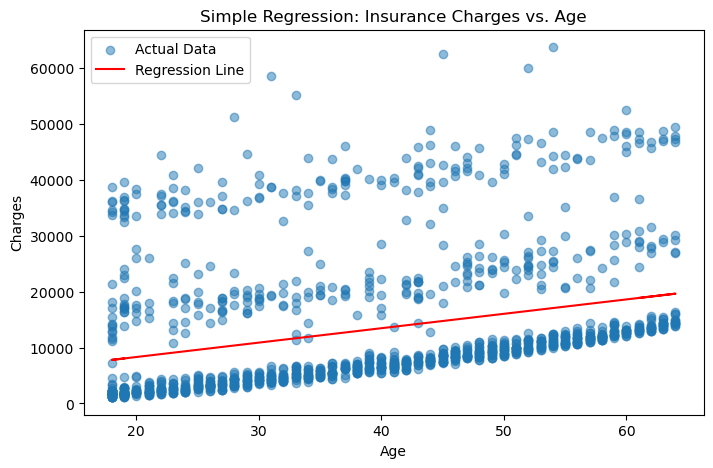

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import RFE

df = pd.read_csv('insurance.csv')

X_age = df[['age']]
y = df['charges']

simple_model = LinearRegression()
simple_model.fit(X_age, y)

print(f"Coefficient (Slope): {simple_model.coef_[0]:.2f}")
print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"R-squared: {simple_model.score(X_age, y):.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['charges'], alpha=0.5, label='Actual Data')
plt.plot(df['age'], simple_model.predict(X_age), color='red', label='Regression Line')
plt.title('Simple Regression: Insurance Charges vs. Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.show()

## 2. The Impact of Smoking Status

<Figure size 800x500 with 0 Axes>

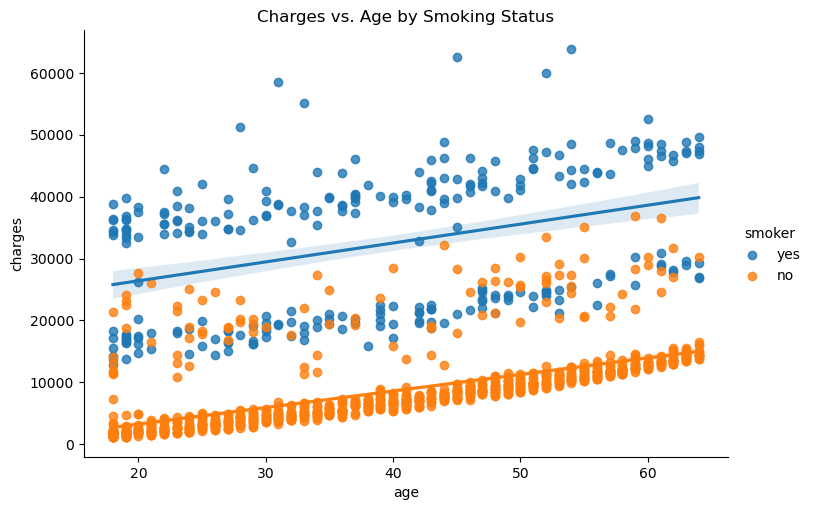

In [2]:
plt.figure(figsize=(8, 5))
sns.lmplot(x='age', y='charges', hue='smoker', data=df, aspect=1.5)
plt.title('Charges vs. Age by Smoking Status')
plt.show()

## Smoking status drastically changes the relationship. Non-smokers form the lowest, most densely populated baseline band. Smokers form the distinct upper bands, meaning that at any given age, a smoker incurs significantly higher medical charges than a non-smoker. The baseline cost for being a smoker jumps by thousands of dollars.

## The Impact of BMI

<Figure size 800x500 with 0 Axes>

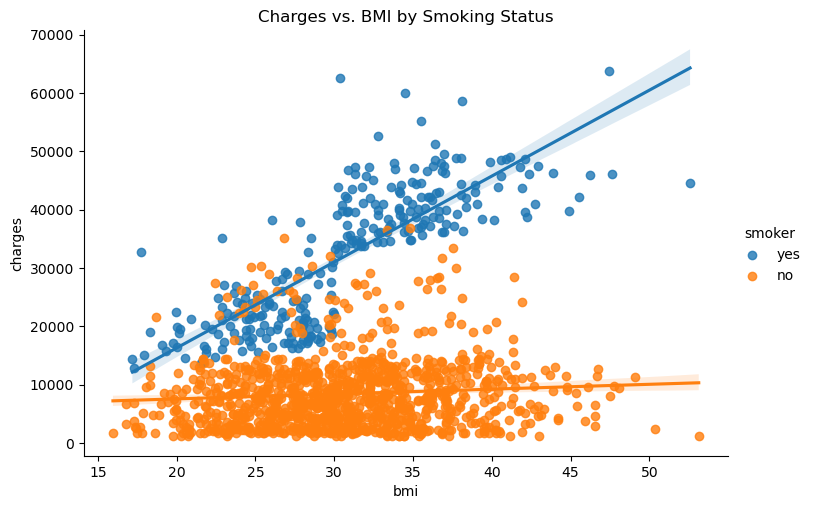

In [7]:
plt.figure(figsize=(8, 5))
sns.lmplot(x='bmi', y='charges', hue='smoker', data=df, aspect=1.5)
plt.title('Charges vs. BMI by Smoking Status')
plt.show()

## BMI has a compounding interactive effect with smoking. For non-smokers, an increase in BMI only causes a slight, gradual increase in medical charges.

## Multiple Regression Model (Encoding & Rescaling)

In [4]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
cols_to_scale = ['age', 'bmi', 'children']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 5. Predictions and Model Evaluation

In [5]:
y_pred = multi_model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Multiple Regression Evaluation ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared: {r2:.4f}")

--- Multiple Regression Evaluation ---
Root Mean Squared Error (RMSE): $5,796.28
Mean Absolute Error (MAE): $4,181.19
R-squared: 0.7836


## The multiple regression model performs significantly better than the simple regression model. The R^2 value should jump to approximately 0.78, meaning the model can explain about 78% of the variance in medical charges using all available features. The MAE tells us that on average the models predictions are off by $4,180ish.

## 6. Optimal Number of Parameters

In [6]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=1)
rfe.fit(X_train_scaled, y_train)

feature_ranks = pd.DataFrame({
    'Feature': X_train_scaled.columns, 
    'Rank': rfe.ranking_
}).sort_values('Rank')

print("--- Feature Importance Ranking ---")
print(feature_ranks)

--- Feature Importance Ranking ---
            Feature  Rank
4        smoker_yes     1
0               age     2
1               bmi     3
2          children     4
7  region_southwest     5
6  region_southeast     6
5  region_northwest     7
3          sex_male     8


## the optimal number of parameters is three to four